# **1. Project Title : Internship Client Project - Churn Prediction**
### **Project Description :**
- In this project, we aim to use machine learning to predict customer churn for No-Churn Telecom. By analyzing customer and service-related features, we identify key factors driving customer migration and generate churn risk scores, including a predictive CHURN-FLAG (YES/NO) to support targeted retention campaigns.

# **2. Project Team Id , Project Id Deadlines**

- **Project Team ID** : PTID-CDS-OCT-25-3171
- **Project ID** : PRCL-0017 – No-Churn Telecom
- **Institute** : DataMites

# **3.Problem Statements and Goals**

- No-Churn Telecom is an established Telecom operator in Europe 
with more than a decade in Business. Due to new players in the 
market, telecom industry  has become very competitive and 
retaining customers becoming a challenge.  
- In spite of No-Churn initiatives of reducing tariffs and promoting 
more offers, the churn rate ( percentage of customers migrating to 
competitors) is well above 10%. 
- No-Churn wants to explore possibility of Machine Learning to help 
with following use cases to retain competitive edge in the industry

### **Goal:**

Help No-Churn with their use cases with ML 
1. Understanding the variables that are influencing the customers 
to migrate. 
2. Creating Churn risk scores that can be indicative to drive 
retention campaigns. 
3. Introduce new predicting  variable “CHURN-FLAG” with values 
YES(1) or NO(0) so that email campaigns with lucrative offers 
can be targeted to Churn YES customers.

# **4. Dataset Source And Description :**

- **Source** : Institute
- **Traget Variable** : "Churn"
- **Description** : Evaluates the probability of customer churn to support retention strategies.

# **Notebook Roadmap** :

1. **Project Title**
2. **Project Team Id, Project Id and Deadlines**
3. **Problem Statements**
4. **Dataset souce and Description**
5. **Imports and Configurations**
6. **Dataset Loading**
7. **Domain Analysis**
8. **Basic checks/ initial inspection**
9. **EDA (Exploratory Data Analysis)**
10. **Feature Engineering**
    - **10.1 Data Preprocessing**
        - **10.1.1 Checking for duplicate rows**
        - **10.1.2 Null Value Handling**
        - **10.1.3 Remove Irrelevant Feature**
        - **10.1.4 Outlier handling**
        - **10.1.5 Scaling**
        - **10.1.6 Encoding**
    - **10.2 Feature Selection**
11. **Modeling**
12. **Modeling Report**
13. **Conclusion , Difficulties And Future Work**

# **5. Imports and Configurations**

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (roc_auc_score,classification_report,confusion_matrix)
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [8]:
pd.set_option("display.max_columns",None)

# **6. Dataset Loading :**

In [10]:
df = pd.read_csv("dataset.csv")
df

,columns1,columns2,columns3,columns4,columns5,columns6,columns7,columns8,columns9,columns10,columns11,columns12,columns13,columns14,columns15,columns16,columns17,columns18,columns19,columns20,columns21
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,NY,57,510,345-7512,no,yes,25,144.0,81,24.48,187.2,112,15.91,158.6,122,7.14,8.5,6,2.30,3,False.
4613,NM,177,408,343-6820,no,yes,29,189.0,91,32.13,303.1,96,25.76,163.6,116,7.36,15.7,1,4.24,3,False.
4614,VT,67,408,338-4794,no,yes,33,127.5,126,21.68,296.1,129,25.17,200.9,91,9.04,13.0,3,3.51,1,False.
4615,MI,98,415,355-8388,no,yes,23,168.9,98,28.71,226.3,117,19.24,165.5,96,7.45,14.3,3,3.86,0,False.


In [11]:
col = ["State","Account Length","Area Code","Phone","International Plan",
"VMail Plan","VMail Message","Day Mins","Day Calls","Day Charge","Eve Mins","Eve Calls",
"Eve Charge","Night Mins","Night Calls","Night Charge","International Mins",
"International calls","International Charge","CustServ Calls","Churn"]

In [12]:
df.columns = col

In [13]:
df

,State,Account Length,Area Code,Phone,International Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,International Mins,International calls,International Charge,CustServ Calls,Churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,NY,57,510,345-7512,no,yes,25,144.0,81,24.48,187.2,112,15.91,158.6,122,7.14,8.5,6,2.30,3,False.
4613,NM,177,408,343-6820,no,yes,29,189.0,91,32.13,303.1,96,25.76,163.6,116,7.36,15.7,1,4.24,3,False.
4614,VT,67,408,338-4794,no,yes,33,127.5,126,21.68,296.1,129,25.17,200.9,91,9.04,13.0,3,3.51,1,False.
4615,MI,98,415,355-8388,no,yes,23,168.9,98,28.71,226.3,117,19.24,165.5,96,7.45,14.3,3,3.86,0,False.


In [14]:
df["Churn"] = df["Churn"].str.strip().str.replace(".", "", regex=False)

In [15]:
df["Churn"] = df["Churn"].map({"True": 1, "False": 0})

In [16]:
df

,State,Account Length,Area Code,Phone,International Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,International Mins,International calls,International Charge,CustServ Calls,Churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,NY,57,510,345-7512,no,yes,25,144.0,81,24.48,187.2,112,15.91,158.6,122,7.14,8.5,6,2.30,3,0
4613,NM,177,408,343-6820,no,yes,29,189.0,91,32.13,303.1,96,25.76,163.6,116,7.36,15.7,1,4.24,3,0
4614,VT,67,408,338-4794,no,yes,33,127.5,126,21.68,296.1,129,25.17,200.9,91,9.04,13.0,3,3.51,1,0
4615,MI,98,415,355-8388,no,yes,23,168.9,98,28.71,226.3,117,19.24,165.5,96,7.45,14.3,3,3.86,0,0


# **7. Domain Analysis**

- State : Typically represents the geographical state (e.g., California, Texas) where the customer lives. It is a categorical variable that is used to determine if a customer's location has any correlation with their likelihood of churning.
  
- Account Length : That represents the duration of time a customer has been with the company. In short it means from how many months customers are joined with company.

- Area code : It refers to the geographical three-digit code associated with a customer's phone number.

- Phone : Represent the number of customers.

- International Plan : It is identified that is there customers have international plan or not.

- VMail Plan : This is a service indicator, A categorical (binary) feature indicating if the customer has a voicemail subscription.

- VMail Message : VMail Message (often labeled as number_vmail_messages) is a numerical feature that counts how many voicemail messages a customer has in their inbox.

- Day Mins : Represents the total number of minutes a customer spends on calls during daytime hours. Higher day-time usage often reflects regular or business-related communication patterns and can influence billing amounts.

- Day Calls : Indicates the total number of calls made by the customer during the day. This helps understand calling frequency independent of total minutes used.

- Day Charge : The total cost incurred by the customer for daytime calls. It is directly derived from Day Mins and reflects the revenue generated from daytime usage.

- Eve Mins : Refers to the total number of minutes spent on calls during evening hours. This captures customer communication behavior outside standard daytime hours.

- Eve Calls : Represents the number of calls made during the evening. It helps analyze customer engagement patterns in non-working hours.

- Eve Charge : The total charge for evening calls, calculated based on evening minutes. It contributes to overall customer billing and revenue.

- Night Mins : Indicates the total minutes of calls made during night hours. Customers with high night usage may prefer off-peak calling.

- Night Calls : Represents the number of calls placed at night, showing how frequently customers communicate during off-peak hours.

- Night Charge : The total cost associated with night-time calls. Typically lower than day charges due to discounted rates.

- International Mins : Shows the total number of minutes spent on international calls. This feature reflects global communication needs and is often linked to higher churn if costs are perceived as high.

- International Calls : Represents the total number of international calls made by the customer. Useful for understanding how frequently customers use international services.

- International Charge : The total cost incurred for international calls. It is an important revenue-driving feature but can also contribute to customer dissatisfaction due to high charges.

- CustServ Calls : Indicates the number of times a customer contacted customer service. A higher count often signals dissatisfaction or service-related issues and is a strong churn indicator.

- Churn : The target variable that indicates whether a customer has left the company (Yes/1) or stayed (No/0). It is used to train and evaluate churn prediction models.

# **8. Basic checks/ Initial Inspection :**

In [20]:
df.shape

(4617, 21)

- **There are 4617 rows and 21 columns in our dataset.**

In [22]:
df.head()

,State,Account Length,Area Code,Phone,International Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,International Mins,International calls,International Charge,CustServ Calls,Churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [23]:
print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


Memory Usage: 1.54 MB


In [24]:
df.tail()

,State,Account Length,Area Code,Phone,International Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,International Mins,International calls,International Charge,CustServ Calls,Churn
4612,NY,57,510,345-7512,no,yes,25,144.0,81,24.48,187.2,112,15.91,158.6,122,7.14,8.5,6,2.30,3,0
4613,NM,177,408,343-6820,no,yes,29,189.0,91,32.13,303.1,96,25.76,163.6,116,7.36,15.7,1,4.24,3,0
4614,VT,67,408,338-4794,no,yes,33,127.5,126,21.68,296.1,129,25.17,200.9,91,9.04,13.0,3,3.51,1,0
4615,MI,98,415,355-8388,no,yes,23,168.9,98,28.71,226.3,117,19.24,165.5,96,7.45,14.3,3,3.86,0,0
4616,IN,140,415,409-6884,no,no,0,204.7,100,34.80,126.8,107,10.78,202.8,115,9.13,12.1,4,3.27,2,0


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4617 entries, 0 to 4616
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   State                 4617 non-null   object 
 1   Account Length        4617 non-null   int64  
 2   Area Code             4617 non-null   int64  
 3   Phone                 4617 non-null   object 
 4   International Plan    4617 non-null   object 
 5   VMail Plan            4617 non-null   object 
 6   VMail Message         4617 non-null   int64  
 7   Day Mins              4617 non-null   float64
 8   Day Calls             4617 non-null   int64  
 9   Day Charge            4617 non-null   float64
 10  Eve Mins              4617 non-null   float64
 11  Eve Calls             4617 non-null   int64  
 12  Eve Charge            4617 non-null   float64
 13  Night Mins            4617 non-null   float64
 14  Night Calls           4617 non-null   int64  
 15  Night Charge         

### Insight: 
* 9 integer columns:
   * Fully populated and most customer engagement intensity
   * CustServ Calls is a high-impact churn driver

* 8 float columns: 
  * Charges are derived from minutes
  * creating multicollinearity risk
  * so retain only one—preferably minutes—for behavior-focused modeling

* 4 object columns:
  * Drop non-predictive identifiers
  * apply advanced encoding to high-cardinality features
    
* missing-values:
  * No missing values across any column
  * Dataset is production-ready with zero imputation overhead

In [27]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Account Length,4617.0,100.645224,39.597194,1.00,74.00,100.00,127.00,243.00
Area Code,4617.0,437.046350,42.288212,408.00,408.00,415.00,510.00,510.00
VMail Message,4617.0,7.849903,13.592333,0.00,0.00,0.00,17.00,51.00
Day Mins,4617.0,180.447152,53.983540,0.00,143.70,180.00,216.80,351.50
Day Calls,4617.0,100.054364,19.883027,0.00,87.00,100.00,113.00,165.00
Day Charge,4617.0,30.676576,9.177145,0.00,24.43,30.60,36.86,59.76
Eve Mins,4617.0,200.429088,50.557001,0.00,165.90,200.80,234.00,363.70
Eve Calls,4617.0,100.179770,19.821314,0.00,87.00,101.00,114.00,170.00
Eve Charge,4617.0,17.036703,4.297332,0.00,14.10,17.07,19.89,30.91
Night Mins,4617.0,200.623933,50.543616,23.20,167.10,200.80,234.90,395.00


### Insights :

- Account Length
    - Average customer tenure is around 100 months, indicating a fairly mature customer base.
    - Wide spread with a standard deviation of ~40 months shows both new and long-term customers exist.
    - Very low minimum value suggests presence of recently joined customers, who are typically more churn-prone.

- Area Code
    - Area codes are limited to 408, 415, and 510, with 415 as the median.
    - Narrow range confirms categorical nature, not a true numerical feature.
    - Should be treated as categorical, not continuous, in modeling.

- VMail Message
    - Median and 25th percentile are 0, meaning most customers do not use voicemail.
    - High standard deviation relative to mean shows few heavy users.
    - Better represented as binary (VMail user vs non-user) than numeric.

- Day Minutes
    - Mean and median are very close (~180 mins), indicating a balanced distribution.
    - Wide range suggests light to heavy daytime users.
    - Heavy day users may be price-sensitive, impacting churn.

- Day Calls
    - Mean around 100 calls, showing stable calling behavior.
    - Zero minimum indicates non-calling customers, possibly data or special plans.
    - Works best when combined with Day Minutes or Charges.

- Day Charge
    - Strongly aligned with Day Minutes, confirming direct linear relationship.
    - High correlation implies multicollinearity risk.
    - One of Minutes or Charge should be dropped for linear models.

- Evening Minutes
    - Average usage (~200 mins) is slightly higher than day usage.
    - Indicates evening is a major calling period for customers.
    - High engagement here may reduce churn unless pricing issues exist.

- Evening Calls
    - Distribution centered around 100 calls, similar to day calls.
    - Low variability suggests consistent user behavior.
    - Moderate standalone predictive power.

- Evening Charge
    - Closely tied to Evening Minutes.
    - Redundant if minutes are already included.
    - Adds billing perspective when churn is cost-driven.

- Night Minutes
    - Mean and median around 200 mins, similar to evening usage.
    - Minimum is relatively high, suggesting most customers use night services.
    - Often associated with discount plans, possibly lowering churn.

- Night Calls
    - Stable distribution around 100 calls.
    - Less variation compared to minutes.
    - Limited predictive power alone.

- Night Charge
    - Low average charge reflects cheaper night tariffs.
    - Narrow range reduces churn sensitivity.
    - Best used only if pricing dissatisfaction is analyzed.

- International Minutes
    - Mean around 10 mins, showing limited international usage.
    - Right-skewed with some high-usage customers.
    - High users may be high-value but churn-sensitive.

- International Calls
    - Median of 4 calls, but maximum goes up to 20.
    - Strong variability indicates niche user group.
    - Works well when bucketed (0, low, high).

- International Charge
    - Closely aligned with international minutes.
    - Small mean but important for billing dissatisfaction analysis.
    - Strong churn signal when combined with International Plan.

- Customer Service Calls
    - Average around 1.5 calls, but maximum reaches 9.
    - Right-skewed distribution indicates few highly dissatisfied customers.
    - One of the strongest churn predictors in telecom datasets.

- Churn
    - Dataset is highly imbalanced.
    - Majority of customers are non-churners.
    - Churners represent a small minority, which can bias models.

In [29]:
df.describe(include="O").T

,count,unique,top,freq
State,4617,51,WV,149
Phone,4617,4617,382-4657,1
International Plan,4617,2,no,4171
VMail Plan,4617,2,no,3381


### Insight :

- State :
    - The dataset contains customers from 51 unique states.
    - WV has the highest number of customers, but it represents only a small portion of the total dataset.
    - State distribution is fairly spread, indicating geographic diversity.
    - State alone is unlikely to be a strong churn predictor but may capture regional effects when grouped.

- Phone :
    - All 4617 phone numbers are unique.
    - Each phone number appears only once.
    - This feature carries no behavioral or predictive information.
    - Should be removed from modeling to reduce noise and dimensionality.

- International Plan
    - Only 2 categories: yes and no.
    - A large majority of customers do not have an international plan.
    - Customers with an international plan form a small but important segment.
    - This feature is useful, as international plan users often show higher churn risk.

- VMail Plan
    - Only 2 categories: yes and no.
    - Most customers do not use voicemail services.
    - Voicemail plan indicates customer engagement level.
    - This feature is valuable for churn prediction and works best as binary.

In [31]:
for i in df.columns:
    print(i ,":", df[i].unique())
    print('-'*50)

State : ['KS' 'OH' 'NJ' 'OK' 'AL' 'MA' 'MO' 'LA' 'WV' 'IN' 'RI' 'IA' 'MT' 'NY'
 'ID' 'VT' 'VA' 'TX' 'FL' 'CO' 'AZ' 'SC' 'NE' 'WY' 'HI' 'IL' 'NH' 'GA'
 'AK' 'MD' 'AR' 'WI' 'OR' 'MI' 'DE' 'UT' 'CA' 'MN' 'SD' 'NC' 'WA' 'NM'
 'NV' 'DC' 'KY' 'ME' 'MS' 'TN' 'PA' 'CT' 'ND']
--------------------------------------------------
Account Length : [128 107 137  84  75 118 121 147 117 141  65  74 168  95  62 161  85  93
  76  73  77 130 111 132 174  57  54  20  49 142 172  12  72  36  78 136
 149  98 135  34 160  64  59 119  97  52  60  10  96  87  81  68 125 116
  38  40  43 113 126 150 138 162  90  50  82 144  46  70  55 106  94 155
  80 104  99 120 108 122 157 103  63 112  41 193  61  92 131 163  91 127
 110 140  83 145  56 151 139   6 115 146 185 148  32  25 179  67  19 170
 164  51 208  53 105  66  86  35  88 123  45 100 215  22  33 114  24 101
 143  48  71 167  89 199 166 158 196 209  16  39 173 129  44  79  31 124
  37 159 194 154  21 133 224  58  11 109 102 165  18  30 176  47 190 152
  26  6

# **9. EDA (Exploratory Data Analysis)**

In [33]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns
print(len(num_cols))
print(len(cat_cols))

17
4


In [34]:
print("Numerical Features:",num_cols)
print("Categorical Features:",cat_cols)

Numerical Features: Index(['Account Length', 'Area Code', 'VMail Message', 'Day Mins', 'Day Calls',
       'Day Charge', 'Eve Mins', 'Eve Calls', 'Eve Charge', 'Night Mins',
       'Night Calls', 'Night Charge', 'International Mins',
       'International calls', 'International Charge', 'CustServ Calls',
       'Churn'],
      dtype='object')
Categorical Features: Index(['State', 'Phone', 'International Plan', 'VMail Plan'], dtype='object')


In [35]:
continuous = [col for col in num_cols if df[col].nunique() > 20]
discrete = [col for col in num_cols if df[col].nunique() <= 20]
print(len(continuous))
print(len(discrete))

14
3


In [36]:
print("Continuous Features:",continuous)
print("Discrete Features:",discrete)

Continuous Features: ['Account Length', 'VMail Message', 'Day Mins', 'Day Calls', 'Day Charge', 'Eve Mins', 'Eve Calls', 'Eve Charge', 'Night Mins', 'Night Calls', 'Night Charge', 'International Mins', 'International calls', 'International Charge']
Discrete Features: ['Area Code', 'CustServ Calls', 'Churn']


# **Univariate Analysis**

## **Continuous Features**

#### **Hist Plot**

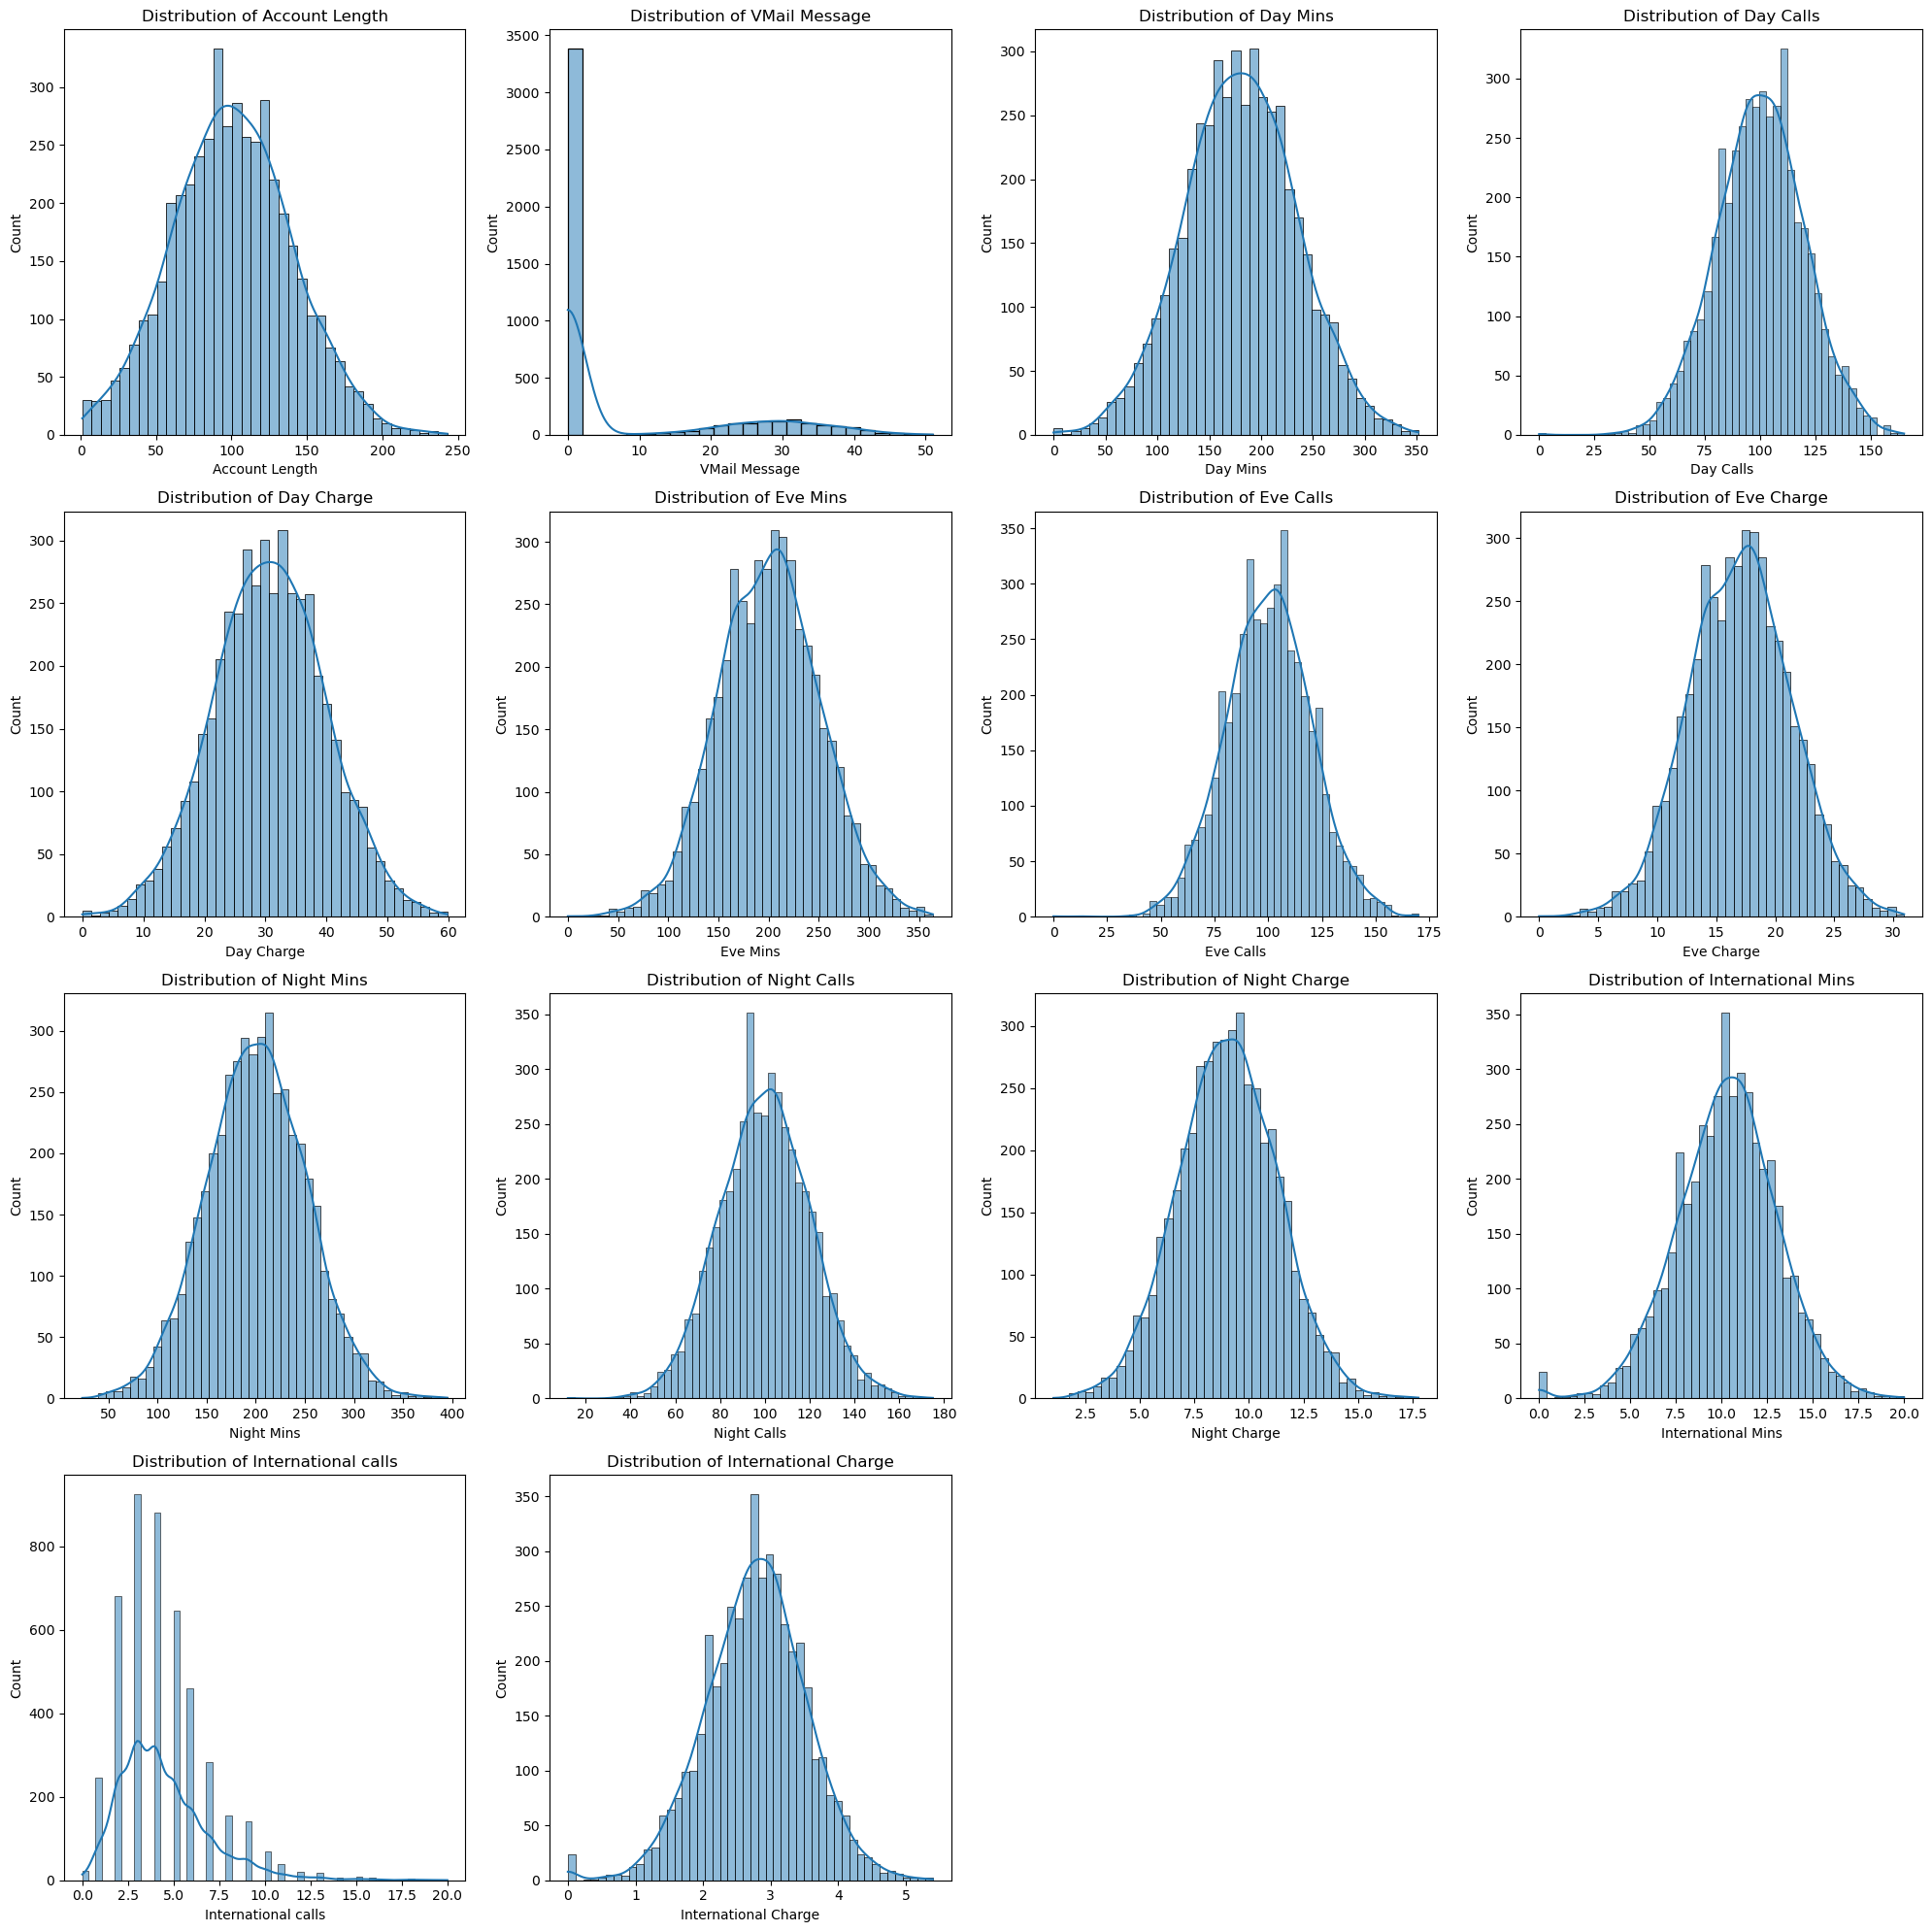

In [40]:
plt.figure(figsize=(20, 20))
plot = 1

for i in continuous:   
    if plot <= 14:
        plt.subplot(4, 4, plot)
        sns.histplot(x=i, data=df,kde=True)   
        plt.title(f"Distribution of {i}")
        plot += 1
plt.subplots_adjust(hspace=0.8)
plt.tight_layout()
plt.show()

### Insight :

- Account Length
    - Distribution is close to normal, indicating customers join and leave at a steady rate.
    - Very few extreme values → no strong outliers.
    - Alone, it may not strongly predict churn, but short-tenure customers often show higher churn tendency when combined with usage or service-call features.


- VMail Messages
    - Highly right-skewed with a large spike at 0 messages.
    - Indicates many customers either don’t use voicemail or have it disabled.
    - This feature works better as a binary indicator (VMail user vs non-user) rather than a continuous variable.
    - Non-VMail users often show higher churn risk in telecom datasets.


- Day Minutes
    - Strong bell-shaped distribution, showing consistent daytime usage.
    - High variance suggests different usage tiers (light vs heavy users).
    - Heavy day-time users may be price-sensitive, increasing churn if charges are high.


- Day Calls
    - Fairly normal distribution with moderate spread.
    - Indicates stable calling behavior; extreme call counts are rare.
    - Works better in interaction with minutes or charges, not alone.


- Day Charge
    - Mirrors Day Minutes, confirming a direct linear relationship.
    - Can be redundant with Day Minutes — keeping both may introduce multicollinearity.
    - For linear models, consider dropping either minutes or charges.


- Evening Minutes
    - Normal distribution, slightly wider than day usage.
    - Suggests evening is a primary calling window for many customers.
    - High evening usage may indicate family/personal dependency on the service.


- Evening Calls
    - Bell-shaped and stable.
    - Less extreme than day calls, meaning evening behavior is more uniform.
    - Useful when combined with customer service calls or churn labels.


- Evening Charge
    - Closely follows evening minutes.
    - Again, highly correlated → consider feature reduction.


- Night Minutes
    - Normal but slightly flatter distribution.
    - Night usage is often linked to discount plans.
    - High night usage with low charges may indicate plan satisfaction, lowering churn.


- Night Calls
    - Mostly centered with limited variance.
    - Night calls alone add limited value but help when combined with night minutes.


- Night Charge
    - Directly dependent on night minutes.
    - Often lower variance → less churn signal individually.


- International Minutes
    - Slight right skew.
    - Small group of users consume most international minutes.
    - These customers are often high-value but price-sensitive.


- International Calls
    - Strongly right-skewed with many near zero.
    - Best treated as a binary or bucketed feature (0, 1–3, 4+).
    - High international calling often correlates with higher churn if pricing is unfavorable.


- International Charge
    - Normal but narrow distribution.
    - Combined with international calls, it can help identify billing dissatisfaction.

## **Discrete Feature**

#### **Count Plot**

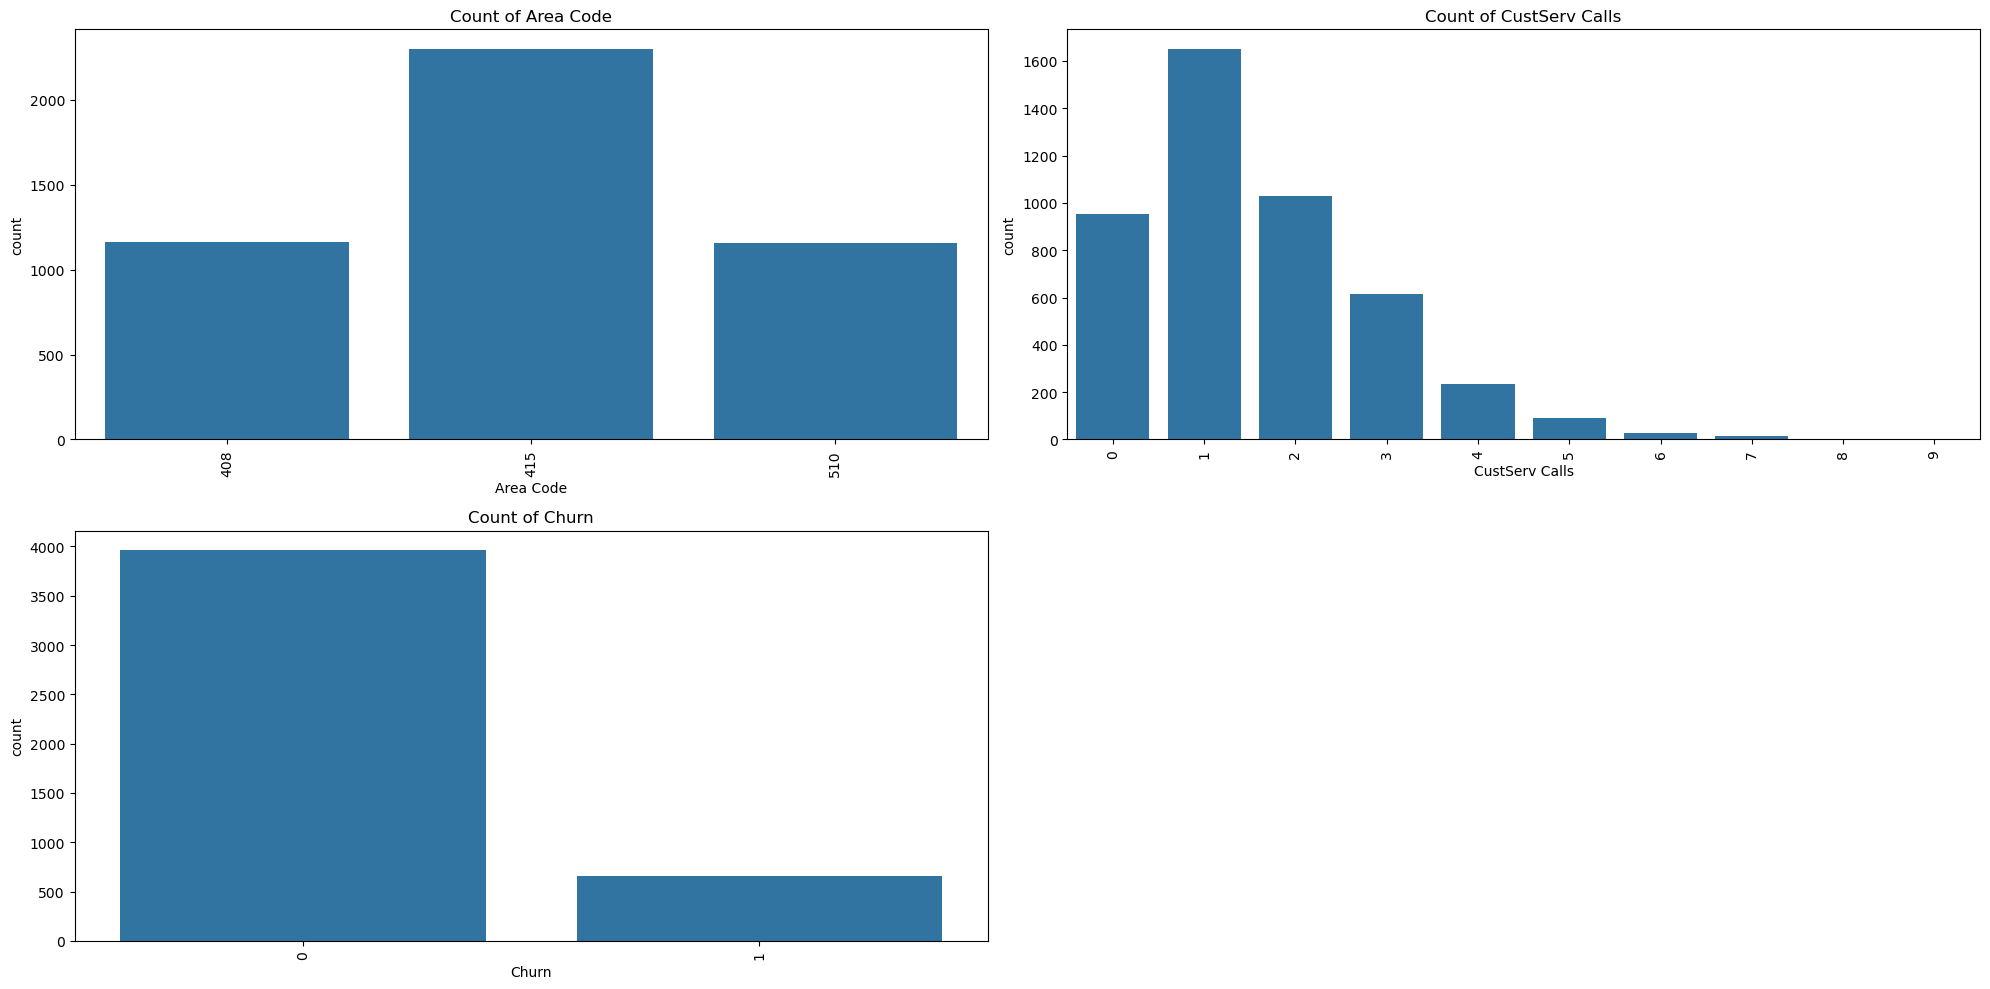

In [44]:
plt.figure(figsize=(20, 10))
plot = 1

for i in discrete:   
    if plot <= 3:
        plt.subplot(2, 2, plot)
        sns.countplot(x=i, data=df)   
        plt.title(f"Count of {i}")
        plt.xticks(rotation=90 )       
        plot += 1
plt.subplots_adjust(hspace=0.2)
plt.tight_layout()
plt.show()

### Insight:

- Area Code: Most customers belong to 415, while 408 and 510 have fewer and similar counts. This shows an uneven geographic distribution.

- Customer Service Calls: Majority of customers make 0–2 calls. Very few make 4+ calls, but these customers are high churn-risk.

- Key Takeaway: Customer service calls is a strong feature for churn prediction; higher calls usually indicate dissatisfaction.

- The Churn shows a strong class imbalance where most customers do not churn, meaning churners are rare and Class imbalance techniques such as SMOTE is recommended.

## **Categorical Feature**

#### **Count Plot**

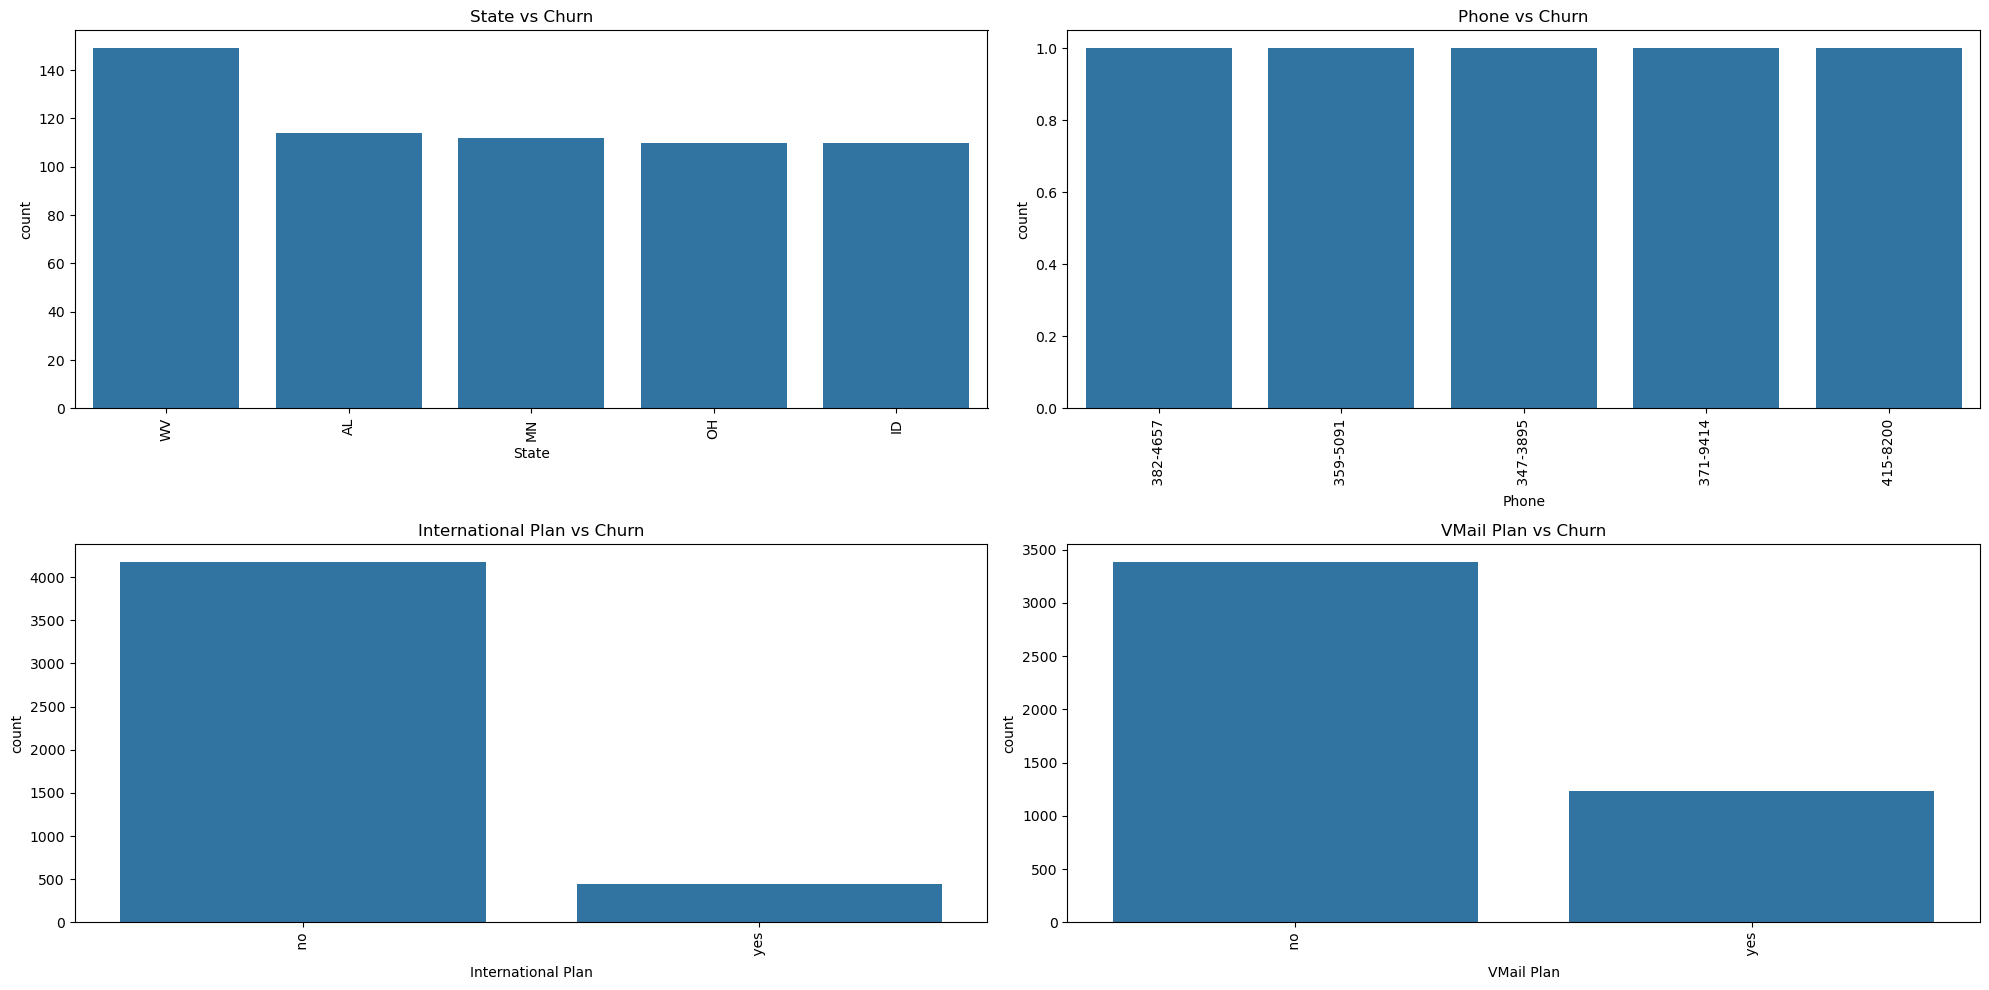

In [48]:
plt.figure(figsize=(20, 10))
plot = 1

for col in cat_cols:
    if plot <= 4:
        top_vals = df[col].value_counts().nlargest(5).index
        df_top = df[df[col].isin(top_vals)]

        plt.subplot(2, 2, plot)
        sns.countplot(
            x=col,
            data=df_top,
            order=top_vals
        )

        plt.title(f"{col} vs Churn", fontsize=12)
        plt.xticks(rotation=90)

        plot += 1

plt.tight_layout()
plt.show()

### Insight :

- State vs Churn
    - Some states such as WV show higher churn counts compared to others.
    - Churn is distributed across multiple states and not concentrated in a single region.
    - State alone is not a strong churn predictor but can reflect regional service quality or competition.
    - This feature is best used after encoding or by grouping states into high, medium, and low churn regions.

- Phone vs Churn
    - Each phone number appears only once in the dataset.
    - The feature has no predictive power for churn.
    - It should be removed from modeling as it increases noise and dimensionality.

- International Plan vs Churn
    - Most customers do not have an international plan.
    - Customers with an international plan churn at a higher rate relative to their population size.
    - This indicates pricing sensitivity or dissatisfaction with international services.
    - This is a strong churn indicator and should be retained as a binary feature.

- VMail Plan vs Churn
    - The majority of customers do not use voicemail services.
    - Customers without a VMail plan show higher churn than those with a plan.
    - This suggests voicemail users are more engaged and more likely to remain loyal.
    - This feature is important for churn prediction and works well as a binary variable.

# **Bivariate Analysis**

## **Discrete Feature**

#### **Bar Plot**

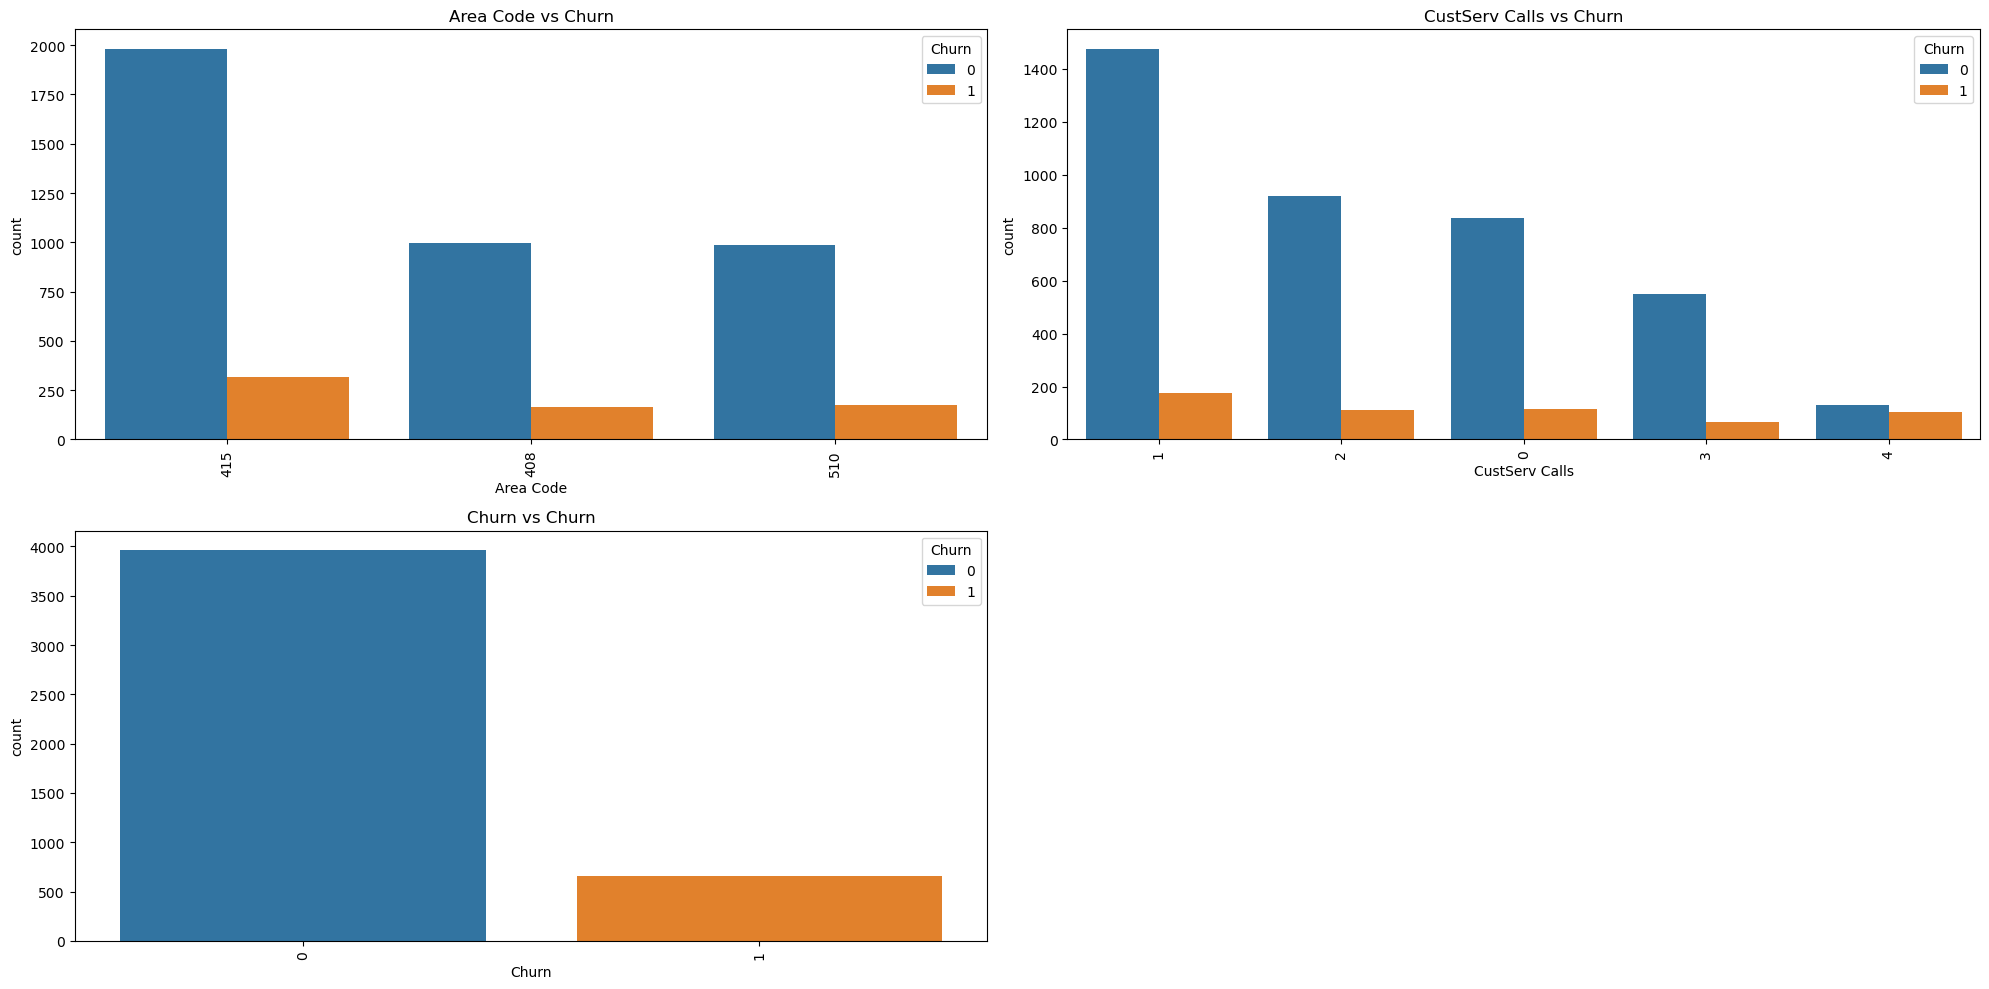

In [53]:
plt.figure(figsize=(20, 10))
plot = 1

for col in discrete:
    if plot <= 3:
        top_vals = df[col].value_counts().nlargest(5).index
        df_top = df[df[col].isin(top_vals)]

        plt.subplot(2, 2, plot)
        sns.countplot(
            x=col,
            hue="Churn",
            data=df_top,
            order=top_vals
        )

        plt.title(f"{col} vs Churn")
        plt.xticks(rotation=90)
        plt.legend(title="Churn")

        plot += 1

plt.tight_layout()
plt.show()

### Insight :

- Area Code vs Churn
    - Area code 415 has the highest number of customers and also the highest churn count.
    - However, churn is present across all area codes (415, 408, 510).
    - The churn rate appears relatively similar across area codes, not extremely skewed toward one.
    - Area code alone is a weak predictor, but it can capture regional patterns when combined with other features.
    - Best used after encoding or grouping into high/medium churn regions.

- Customer Service Calls vs Churn
    - Customers with 1 or 2 service calls mostly do not churn.
    - Churn probability increases significantly as the number of service calls increases.
    - Customers with 3 or more calls show a much higher churn proportion.
    - Customers with 4 calls have fewer total records but a very high churn ratio.
    - This feature shows a strong monotonic relationship with churn.
    - Customer service calls is one of the strongest churn predictors and should be retained.
    - Creating a feature like High_CustServ_Calls (>=3) can improve model performance.

## **Categorical Feature**

#### **Bar Plot**

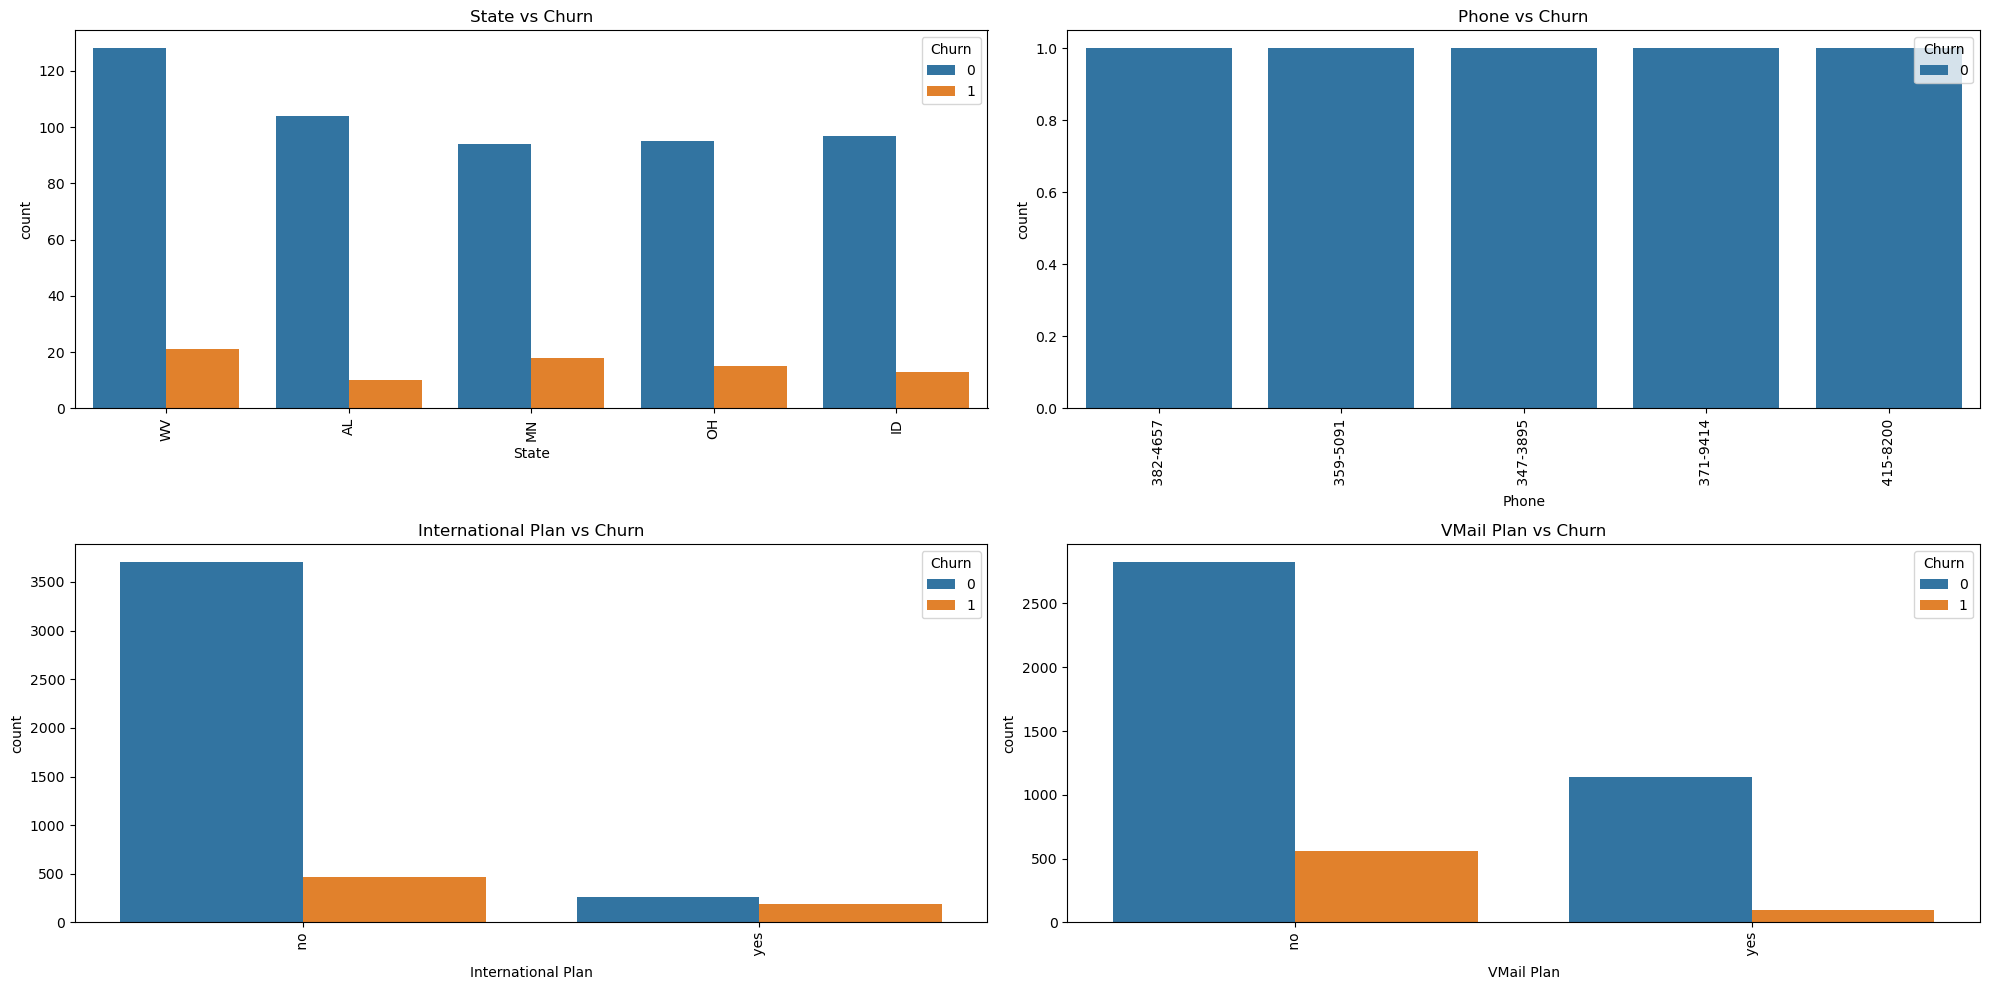

In [57]:
plt.figure(figsize=(20, 10))
plot = 1

for col in cat_cols:
    if plot <= 4:
        top_vals = df[col].value_counts().nlargest(5).index
        df_top = df[df[col].isin(top_vals)]

        plt.subplot(2, 2, plot)
        sns.countplot(
            x=col,
            hue="Churn",
            data=df_top,
            order=top_vals
        )

        plt.title(f"{col} vs Churn")
        plt.xticks(rotation=90)
        plt.legend(title="Churn")

        plot += 1

plt.tight_layout()
plt.show()

### Insight :

- State vs Churn
    - Certain states like WV show comparatively higher churn counts than others.
    - Churn is present across all states, not limited to a single region.
    - Indicates that state-level factors such as network quality, competition, or customer demographics may influence churn.
    - State alone is a weak predictor, but grouping states into churn-risk bands can improve usefulness.

- Phone vs Churn
    - Each phone number is unique and appears only once.
    - There is no relationship between phone number and churn.
    - This feature carries no predictive signal.
    - Should be removed from modeling to reduce noise and dimensionality.

- International Plan vs Churn
    - Majority of customers do not have an international plan.
    - Customers with an international plan show a much higher churn proportion.
    - Suggests pricing dissatisfaction or high cost sensitivity among international plan users.
    - This is a strong churn-driving feature and should be retained as a binary variable.

- VMail Plan vs Churn
    - Most customers do not subscribe to the voicemail plan.
    - Customers without a VMail plan churn significantly more than those with it.
    - Indicates that VMail users are more engaged and loyal.
    - This feature is important for churn prediction and effective in binary form.

# **10. Feature Engineering**

## **10.1 Data Preprocessing**

### **10.1.1 Checking for duplicate rows**

In [62]:
duplicates = df.duplicated().sum()
duplicates

0

- **There are not any duplicate entries in dataset.**

### **10.1.2 Null value handling**

In [65]:
missing = df.isna().sum().sort_values(ascending=False)
missing

State                   0
Eve Calls               0
CustServ Calls          0
International Charge    0
International calls     0
International Mins      0
Night Charge            0
Night Calls             0
Night Mins              0
Eve Charge              0
Eve Mins                0
Account Length          0
Day Charge              0
Day Calls               0
Day Mins                0
VMail Message           0
VMail Plan              0
International Plan      0
Phone                   0
Area Code               0
Churn                   0
dtype: int64

- **There are not any null values in our dataset.**

### **10.1.3 Remove Irrelevant Feature**

In [68]:
df.drop(["Phone","Day Calls","Eve Calls","Night Calls","Area Code"], axis = 1, inplace = True)

- There are all unique values in , so there is no variance in "Phone" feature. We can drop it.

In [70]:
df

,State,Account Length,International Plan,VMail Plan,VMail Message,Day Mins,Day Charge,Eve Mins,Eve Charge,Night Mins,Night Charge,International Mins,International calls,International Charge,CustServ Calls,Churn
0,KS,128,no,yes,25,265.1,45.07,197.4,16.78,244.7,11.01,10.0,3,2.70,1,0
1,OH,107,no,yes,26,161.6,27.47,195.5,16.62,254.4,11.45,13.7,3,3.70,1,0
2,NJ,137,no,no,0,243.4,41.38,121.2,10.30,162.6,7.32,12.2,5,3.29,0,0
3,OH,84,yes,no,0,299.4,50.90,61.9,5.26,196.9,8.86,6.6,7,1.78,2,0
4,OK,75,yes,no,0,166.7,28.34,148.3,12.61,186.9,8.41,10.1,3,2.73,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,NY,57,no,yes,25,144.0,24.48,187.2,15.91,158.6,7.14,8.5,6,2.30,3,0
4613,NM,177,no,yes,29,189.0,32.13,303.1,25.76,163.6,7.36,15.7,1,4.24,3,0
4614,VT,67,no,yes,33,127.5,21.68,296.1,25.17,200.9,9.04,13.0,3,3.51,1,0
4615,MI,98,no,yes,23,168.9,28.71,226.3,19.24,165.5,7.45,14.3,3,3.86,0,0


### **10.1.4 Outliers Handling**

In [72]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
numeric_cols

Index(['Account Length', 'VMail Message', 'Day Mins', 'Day Charge', 'Eve Mins',
       'Eve Charge', 'Night Mins', 'Night Charge', 'International Mins',
       'International calls', 'International Charge', 'CustServ Calls',
       'Churn'],
      dtype='object')

In [73]:
continuous_cols = [col for col in numeric_cols if df[col].nunique() > 20]
continuous_cols

['Account Length',
 'VMail Message',
 'Day Mins',
 'Day Charge',
 'Eve Mins',
 'Eve Charge',
 'Night Mins',
 'Night Charge',
 'International Mins',
 'International calls',
 'International Charge']

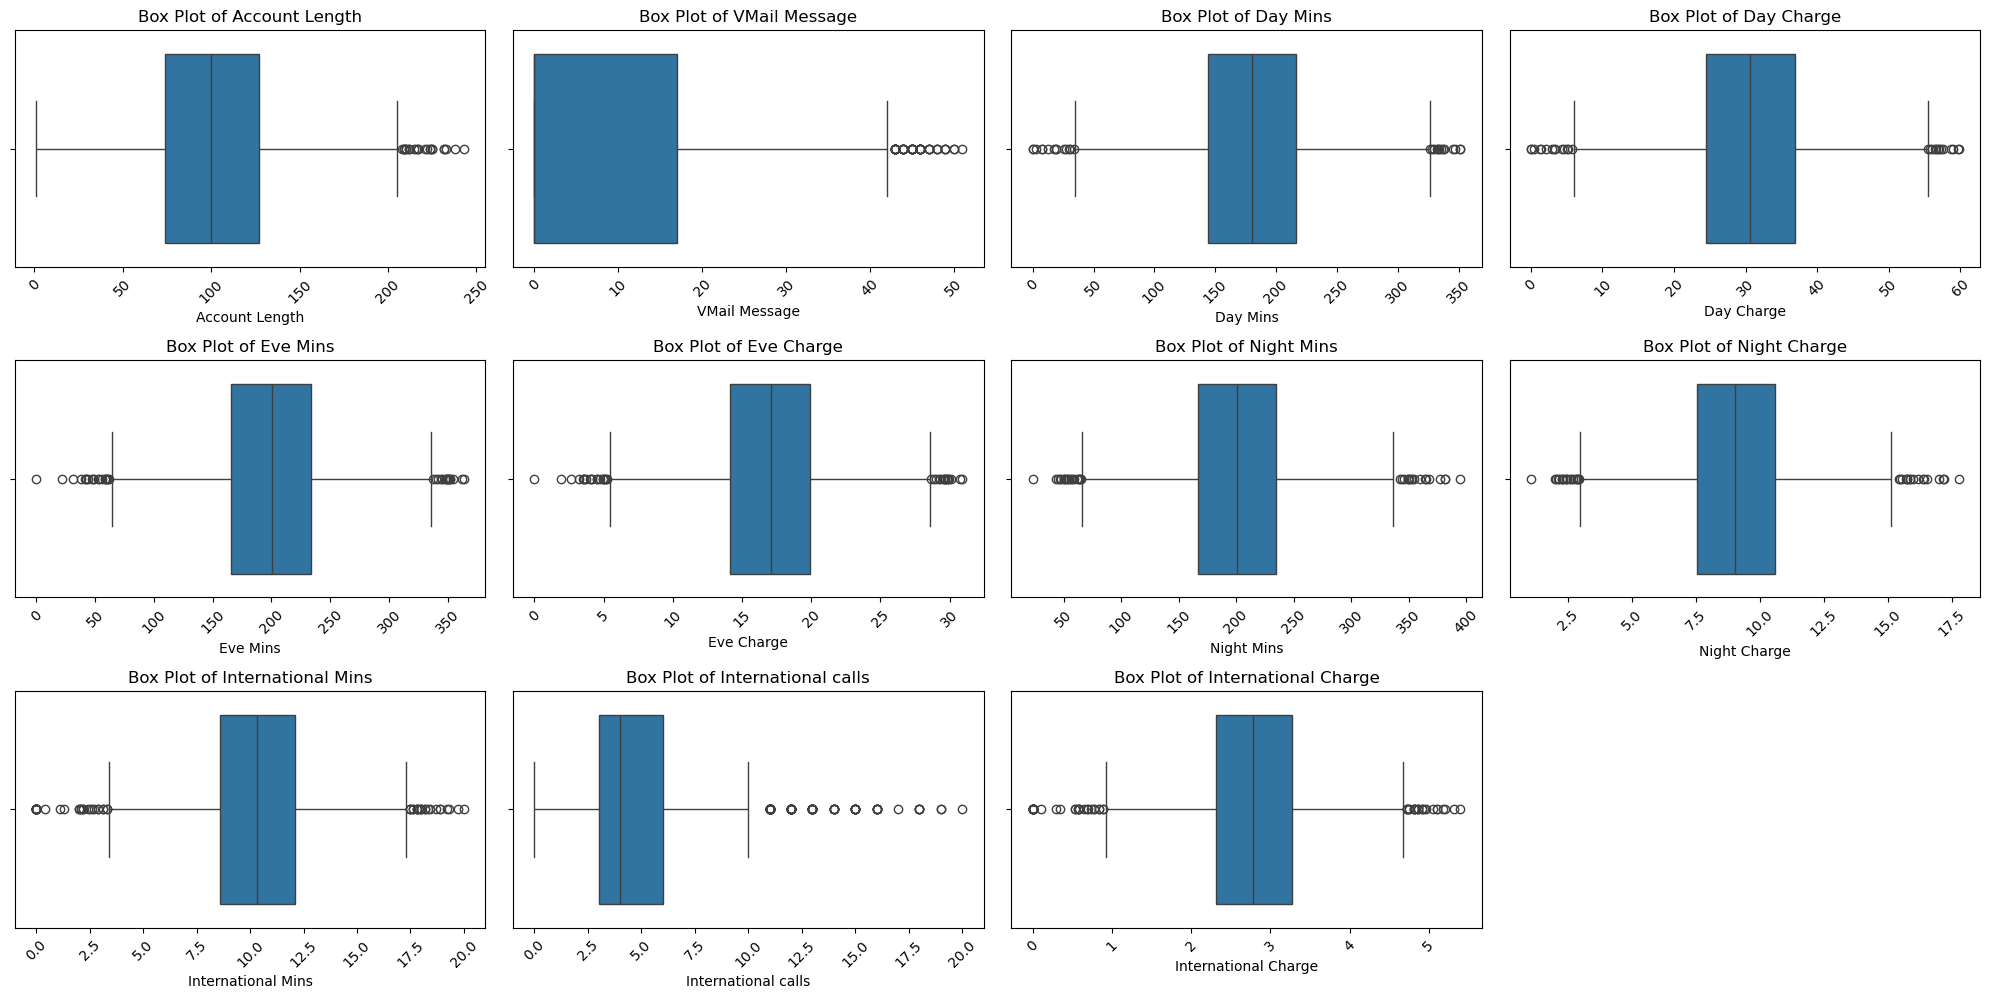

In [74]:
plt.figure(figsize=(20, 10))
plot = 1

for i in continuous_cols:   
    if plot <= 11:
        plt.subplot(3, 4, plot)
        sns.boxplot(x=i, data=df)
        plt.title(f"Box Plot of {i}")
        plt.xticks(rotation=45)
        plot += 1
plt.subplots_adjust(hspace=0.8)
plt.tight_layout()
plt.show()

In [75]:
def outlier_ratio(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((df[col] < lower) | (df[col] > upper)).mean() * 100

ratios = {col: outlier_ratio(col) for col in continuous_cols}
ratios_df = pd.DataFrame(ratios.items(), columns=['Column', 'Outlier_%']).sort_values('Outlier_%', ascending=False)
ratios_df.head(30)

,Column,Outlier_%
9,International calls,2.317522
8,International Mins,1.407841
10,International Charge,1.407841
1,VMail Message,1.104613
4,Eve Mins,0.779727
5,Eve Charge,0.779727
6,Night Mins,0.779727
7,Night Charge,0.779727
2,Day Mins,0.584795
3,Day Charge,0.584795


In [76]:
outlier_cols = ['International calls',
                'International Mins',
                'Eve Mins',
                'Night Mins',
                'Day Mins',
                'Account Length']

In [77]:
for i in outlier_cols :
    Q1 = df[i].quantile(.25)
    Q3 = df[i].quantile(.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5* IQR
    upper_bound = Q3 + 1.5* IQR

    df.loc[df[i] > upper_bound,i] = upper_bound
    df.loc[df[i] < lower_bound,i] = lower_bound

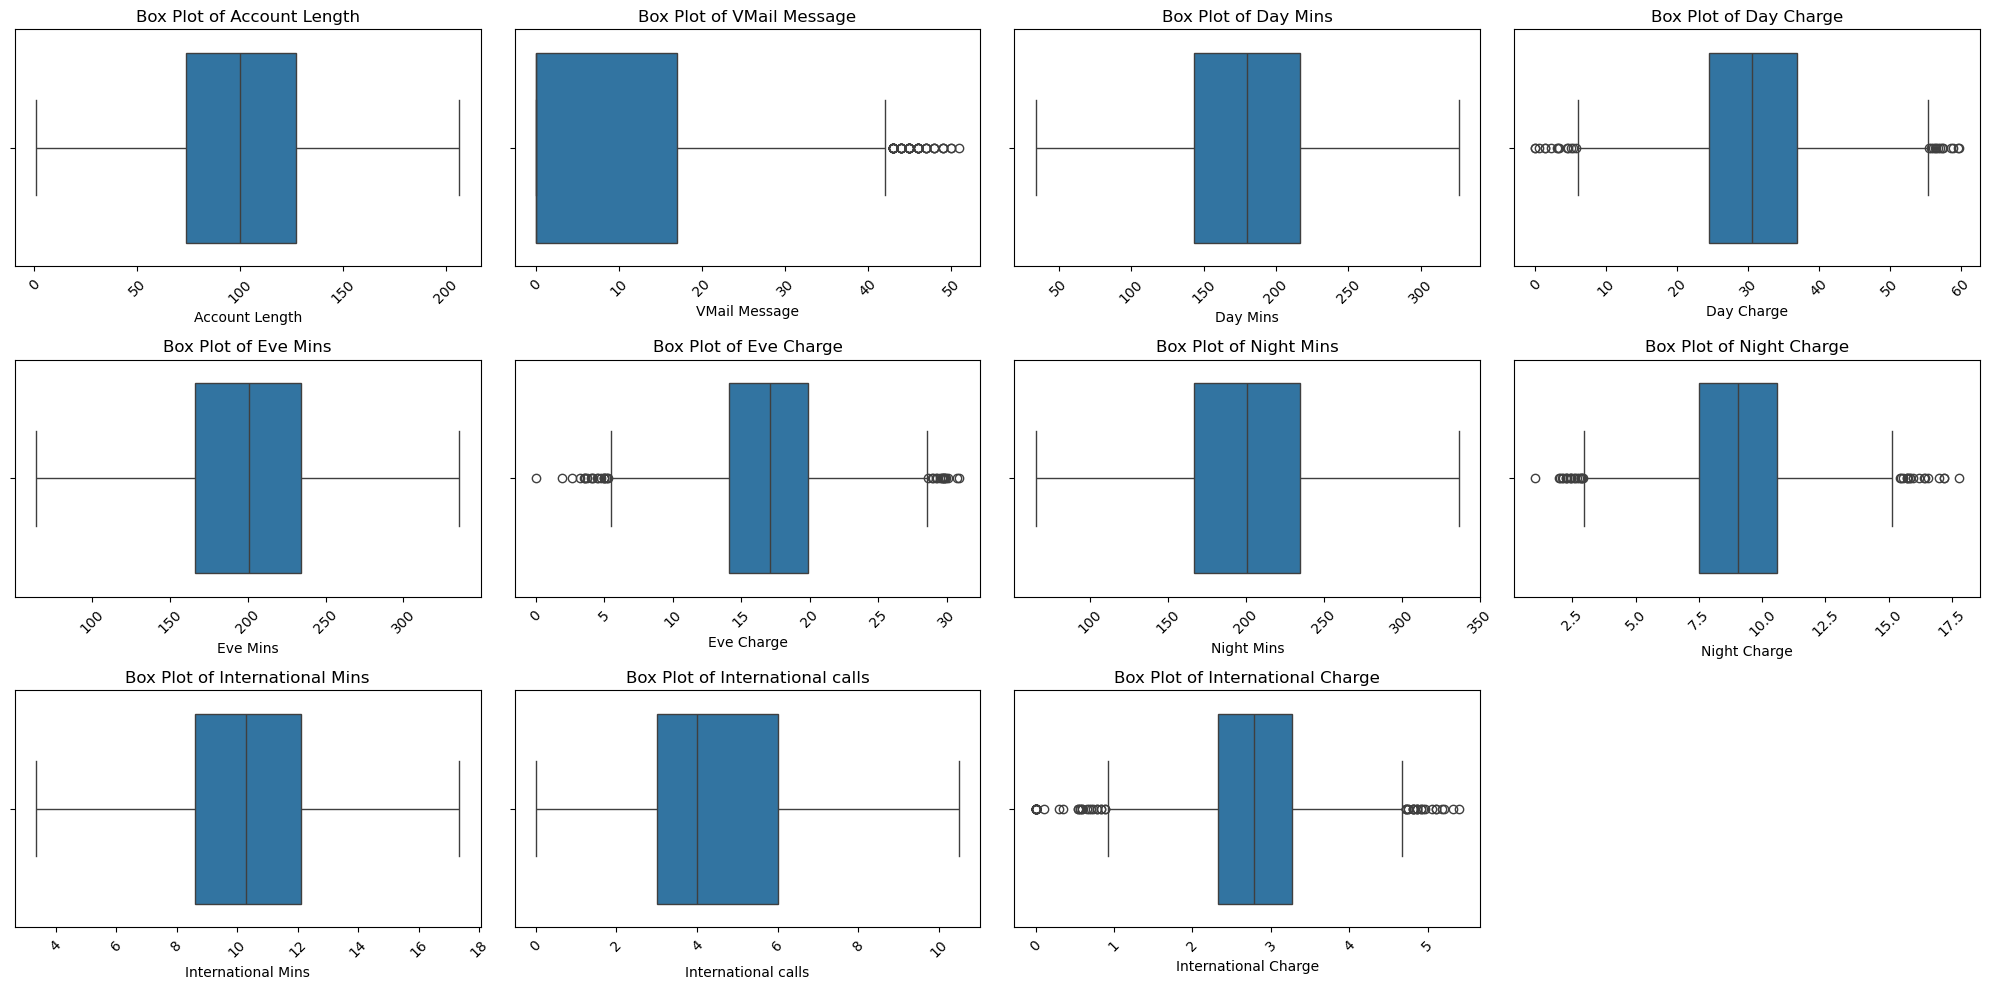

In [78]:
plt.figure(figsize=(20, 10))
plot = 1

for i in continuous_cols:   
    if plot <= 11:
        plt.subplot(3, 4, plot)
        sns.boxplot(x=i, data=df)
        plt.title(f"Box Plot of {i}")
        plt.xticks(rotation=45)       
        plot += 1
plt.subplots_adjust(hspace=0.8)
plt.tight_layout()
plt.show()

### **10.1.5 Scaling**

In [80]:
df

,State,Account Length,International Plan,VMail Plan,VMail Message,Day Mins,Day Charge,Eve Mins,Eve Charge,Night Mins,Night Charge,International Mins,International calls,International Charge,CustServ Calls,Churn
0,KS,128.0,no,yes,25,265.1,45.07,197.40,16.78,244.7,11.01,10.0,3.0,2.70,1,0
1,OH,107.0,no,yes,26,161.6,27.47,195.50,16.62,254.4,11.45,13.7,3.0,3.70,1,0
2,NJ,137.0,no,no,0,243.4,41.38,121.20,10.30,162.6,7.32,12.2,5.0,3.29,0,0
3,OH,84.0,yes,no,0,299.4,50.90,63.75,5.26,196.9,8.86,6.6,7.0,1.78,2,0
4,OK,75.0,yes,no,0,166.7,28.34,148.30,12.61,186.9,8.41,10.1,3.0,2.73,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,NY,57.0,no,yes,25,144.0,24.48,187.20,15.91,158.6,7.14,8.5,6.0,2.30,3,0
4613,NM,177.0,no,yes,29,189.0,32.13,303.10,25.76,163.6,7.36,15.7,1.0,4.24,3,0
4614,VT,67.0,no,yes,33,127.5,21.68,296.10,25.17,200.9,9.04,13.0,3.0,3.51,1,0
4615,MI,98.0,no,yes,23,168.9,28.71,226.30,19.24,165.5,7.45,14.3,3.0,3.86,0,0


- There is not need for scaling in any features.

### **10.1.6 Encoding**

In [83]:
df["VMail Plan"] = df["VMail Plan"].str.strip()
df["International Plan"] = df["International Plan"].str.strip()

In [84]:
df["VMail Plan"] = df["VMail Plan"].map({"yes": 1, "no": 0})
df["International Plan"] = df["International Plan"].map({"yes": 1, "no": 0})

In [85]:
df = pd.get_dummies(df, columns=["State"], prefix="State", drop_first=True)

In [86]:
df = df.astype({col: int for col in df.select_dtypes('bool').columns})

In [87]:
df

,Account Length,International Plan,VMail Plan,VMail Message,Day Mins,Day Charge,Eve Mins,Eve Charge,Night Mins,Night Charge,International Mins,International calls,International Charge,CustServ Calls,Churn,State_AL,State_AR,State_AZ,State_CA,State_CO,State_CT,State_DC,State_DE,State_FL,State_GA,State_HI,State_IA,State_ID,State_IL,State_IN,State_KS,State_KY,State_LA,State_MA,State_MD,State_ME,State_MI,State_MN,State_MO,State_MS,State_MT,State_NC,State_ND,State_NE,State_NH,State_NJ,State_NM,State_NV,State_NY,State_OH,State_OK,State_OR,State_PA,State_RI,State_SC,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY
0,128.0,0,1,25,265.1,45.07,197.40,16.78,244.7,11.01,10.0,3.0,2.70,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,107.0,0,1,26,161.6,27.47,195.50,16.62,254.4,11.45,13.7,3.0,3.70,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,137.0,0,0,0,243.4,41.38,121.20,10.30,162.6,7.32,12.2,5.0,3.29,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,84.0,1,0,0,299.4,50.90,63.75,5.26,196.9,8.86,6.6,7.0,1.78,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,75.0,1,0,0,166.7,28.34,148.30,12.61,186.9,8.41,10.1,3.0,2.73,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,57.0,0,1,25,144.0,24.48,187.20,15.91,158.6,7.14,8.5,6.0,2.30,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4613,177.0,0,1,29,189.0,32.13,303.10,25.76,163.6,7.36,15.7,1.0,4.24,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4614,67.0,0,1,33,127.5,21.68,296.10,25.17,200.9,9.04,13.0,3.0,3.51,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4615,98.0,0,1,23,168.9,28.71,226.30,19.24,165.5,7.45,14.3,3.0,3.86,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## **10.2 Feature selection**

In [89]:
corr_matrix = df.corr()
high_corr = corr_matrix[abs(corr_matrix) >= 0.9]
high_corr_pairs = high_corr.stack().reset_index()
high_corr_pairs.columns = ['Column 1', 'Column 2', 'Correlation']
high_corr_pairs = high_corr_pairs[high_corr_pairs['Column 1'] != high_corr_pairs['Column 2']]
high_corr_pairs = high_corr_pairs.sort_values(by='Correlation', key=abs, ascending=False)

print(high_corr_pairs)

                Column 1              Column 2  Correlation
7               Day Mins            Day Charge     0.999693
8             Day Charge              Day Mins     0.999693
11              Eve Mins            Eve Charge     0.999432
12            Eve Charge              Eve Mins     0.999432
15            Night Mins          Night Charge     0.999248
16          Night Charge            Night Mins     0.999248
19    International Mins  International Charge     0.995717
21  International Charge    International Mins     0.995717
3             VMail Plan         VMail Message     0.955280
4          VMail Message            VMail Plan     0.955280


In [90]:
target_corr = df.corr()["Churn"]

In [91]:
drop_cols = []

for _, row in high_corr_pairs.iterrows():
    col1 = row["Column 1"]
    col2 = row["Column 2"]

    if col1 in drop_cols or col2 in drop_cols:
        continue

    corr1 = abs(target_corr[col1])
    corr2 = abs(target_corr[col2])

    if corr1 >= corr2:
        drop_cols.append(col2)
    else:
        drop_cols.append(col1)

In [92]:
drop_cols = list(set(drop_cols))

In [93]:
print("Columns to drop based on lower correlation with target:")
print(drop_cols)

Columns to drop based on lower correlation with target:
['Night Charge', 'Eve Mins', 'International Mins', 'VMail Message', 'Day Mins']


In [94]:
df.drop(columns=drop_cols, inplace=True)
df

,Account Length,International Plan,VMail Plan,Day Charge,Eve Charge,Night Mins,International calls,International Charge,CustServ Calls,Churn,State_AL,State_AR,State_AZ,State_CA,State_CO,State_CT,State_DC,State_DE,State_FL,State_GA,State_HI,State_IA,State_ID,State_IL,State_IN,State_KS,State_KY,State_LA,State_MA,State_MD,State_ME,State_MI,State_MN,State_MO,State_MS,State_MT,State_NC,State_ND,State_NE,State_NH,State_NJ,State_NM,State_NV,State_NY,State_OH,State_OK,State_OR,State_PA,State_RI,State_SC,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY
0,128.0,0,1,45.07,16.78,244.7,3.0,2.70,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,107.0,0,1,27.47,16.62,254.4,3.0,3.70,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,137.0,0,0,41.38,10.30,162.6,5.0,3.29,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,84.0,1,0,50.90,5.26,196.9,7.0,1.78,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,75.0,1,0,28.34,12.61,186.9,3.0,2.73,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,57.0,0,1,24.48,15.91,158.6,6.0,2.30,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4613,177.0,0,1,32.13,25.76,163.6,1.0,4.24,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4614,67.0,0,1,21.68,25.17,200.9,3.0,3.51,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4615,98.0,0,1,28.71,19.24,165.5,3.0,3.86,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


# **11. Modeling**

In [96]:
y = df['Churn']
X = df.drop('Churn', axis=1)

In [97]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [98]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

In [99]:
model_results = {
    "Model": [],
    "Type": [],
    "ROC_AUC": []
}

In [100]:
log_clf = LogisticRegression(max_iter=500, n_jobs=-1)
log_clf.fit(X_train_sm, y_train_sm)
log_pred = log_clf.predict(X_test)

print("Logistic Regression (No Tuning)")
print(classification_report(y_test, log_pred))
log_auc = roc_auc_score(y_test, log_clf.predict_proba(X_test)[:, 1])
print("AUC:", log_auc)

model_results["Model"].append("Logistic Regression")
model_results["Type"].append("Baseline")
model_results["ROC_AUC"].append(log_auc)

Logistic Regression (No Tuning)
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       793
           1       0.36      0.40      0.38       131

    accuracy                           0.82       924
   macro avg       0.63      0.64      0.64       924
weighted avg       0.82      0.82      0.82       924

AUC: 0.7295900195412147


In [101]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_sm, y_train_sm)
dt_pred = dt.predict(X_test)

print("Decision Tree (No Tuning)")
print(classification_report(y_test, dt_pred))
dt_auc = roc_auc_score(y_test, dt.predict_proba(X_test)[:, 1])
print("AUC:", dt_auc)

model_results["Model"].append("Decision Tree")
model_results["Type"].append("Baseline")
model_results["ROC_AUC"].append(dt_auc)

Decision Tree (No Tuning)
              precision    recall  f1-score   support

           0       0.96      0.89      0.92       793
           1       0.53      0.76      0.62       131

    accuracy                           0.87       924
   macro avg       0.74      0.82      0.77       924
weighted avg       0.90      0.87      0.88       924

AUC: 0.8230076143353581


In [102]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_sm, y_train_sm)
rf_pred = rf.predict(X_test)

print("Random Forest (No Tuning)")
print(classification_report(y_test, rf_pred))
print("AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

model_results["Model"].append("Random Forest")
model_results["Type"].append("Baseline")
model_results["ROC_AUC"].append(rf_auc)

Random Forest (No Tuning)
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       793
           1       0.71      0.77      0.74       131

    accuracy                           0.92       924
   macro avg       0.83      0.86      0.85       924
weighted avg       0.93      0.92      0.92       924

AUC: 0.8953438002368048


In [103]:
gb = GradientBoostingClassifier()
gb.fit(X_train_sm, y_train_sm)
gb_pred = gb.predict(X_test)

print("Gradient Boosting (No Tuning)")
print(classification_report(y_test, gb_pred))
gb_auc = roc_auc_score(y_test, gb.predict_proba(X_test)[:, 1])
print("AUC:", gb_auc)

model_results["Model"].append("Gradient Boosting")
model_results["Type"].append("Baseline")
model_results["ROC_AUC"].append(gb_auc)

Gradient Boosting (No Tuning)
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       793
           1       0.69      0.79      0.73       131

    accuracy                           0.92       924
   macro avg       0.83      0.86      0.84       924
weighted avg       0.92      0.92      0.92       924

AUC: 0.8914355573096657


In [104]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

In [105]:
xgb = XGBClassifier(
    eval_metric='logloss',
    tree_method='hist',
    scale_pos_weight=scale_pos_weight,
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    n_jobs=-1,
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print("XGBoost (No Tuning)")
print(classification_report(y_test, xgb_pred))
xgb_auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])
print("AUC:", xgb_auc)

model_results["Model"].append("XGBoost")
model_results["Type"].append("Baseline")
model_results["ROC_AUC"].append(xgb_auc)

XGBoost (No Tuning)
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       793
           1       0.80      0.79      0.80       131

    accuracy                           0.94       924
   macro avg       0.88      0.88      0.88       924
weighted avg       0.94      0.94      0.94       924

AUC: 0.9067893688091411


In [106]:
model_results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "ROC_AUC": [
        log_auc,
        dt_auc,
        rf_auc,
        gb_auc,
        xgb_auc,
    ]
}

results_df = pd.DataFrame(model_results)
results_df = results_df.sort_values(by="ROC_AUC", ascending=False)
print(results_df)

                 Model   ROC_AUC
4              XGBoost  0.906789
2        Random Forest  0.895344
3    Gradient Boosting  0.891436
1        Decision Tree  0.823008
0  Logistic Regression  0.729590


# **12. Modeling Report**

### **Telecom Customer Churn Prediction – Project Report**

- The main objective of this project was to build a reliable machine learning model to predict whether a telecom customer is likely to churn. The analysis used customer service plans, call usage patterns (day, evening, night, and international), customer tenure, and customer service interaction data. Since churned customers form a smaller portion of the dataset, special attention was given to handling class imbalance and evaluating models using appropriate performance metrics such as ROC–AUC, precision, recall, and confusion matrices.

- The project workflow was structured into the following major stages:
## **Feature Engineering**

- Data cleaning:
    - Formatting issues such as extra spaces and punctuation in categorical variables were corrected. Binary categorical features were standardized and the target variable (Churn) was converted into numeric form for modeling.

- Outlier handling:
    - Usage-based numerical features showed a small percentage of extreme values. As these represented genuine customer behavior, outliers were managed using mild capping rather than removal. Charge-related variables were dropped as they were directly derived from usage minutes and added no independent information.

- Encoding categorical variables:
    - Binary features such as International Plan and VMail Plan were encoded as 0/1. The State feature was transformed using one-hot encoding, and the original State column was removed to ensure the dataset was fully numeric.

- Feature reduction:
    - Highly correlated feature pairs were identified using correlation analysis. For each pair, correlation with the churn target was compared, and the feature with lower predictive strength was removed to reduce multicollinearity while preserving relevant churn signals.

## **Modeling**
- The churn variable was highly imbalanced, with significantly fewer churned customers than non-churned ones. To address this, SMOTE was applied only on the training data to balance the classes while keeping test data realistic.
- The following models were trained and evaluated:
    - Logistic Regression
    - Decision Tree
    - Random Forest
    - Gradient Boosting
    - XGBoost (configured for faster execution and strong performance)

- The dataset was split using stratified sampling to maintain the churn ratio in both training and test sets. Limited hyperparameter tuning was applied to selected models to improve performance without significantly increasing training time.

## **Model Evaluation**
- Model performance was evaluated using multiple metrics:
    - ROC–AUC, to measure the model’s ability to distinguish between churn and non-churn customers.
    - Precision, Recall, and F1-score, with emphasis on the churn class.
    - Confusion Matrix, to analyze correct and incorrect predictions.

- Among the evaluated models, boosting-based models, particularly XGBoost, demonstrated the strongest performance. Random Forest and Gradient Boosting also performed well, capturing non-linear relationships in customer behavior. Logistic Regression provided a strong baseline and interpretability.

# **13. Conclusion, Difficulties, and Future Work**

## **Conclusion**
- This project successfully built an end-to-end telecom customer churn prediction pipeline using customer tenure, service plans, call usage patterns (day, evening, night, and international), and customer service interaction data. Proper feature cleaning, encoding, and correlation-based feature reduction helped the models learn meaningful churn-related patterns.

- Ensemble and boosting-based models, particularly XGBoost and Gradient Boosting, delivered strong and stable performance. The results highlight that customer usage behavior and service-related interactions play a critical role in predicting churn, and careful handling of imbalance and redundancy significantly improves model quality.

## **Difficulties We Faced**
- Imbalanced data:
    - Churned customers were far fewer than retained customers, requiring the use of SMOTE and evaluation metrics beyond accuracy, such as ROC–AUC, precision, and recall.

- Highly correlated features:
    - Several usage and charge-related features were strongly correlated. We had to carefully analyze feature–feature and feature–target correlations to remove redundant variables without losing predictive information.

- Categorical data handling:
    - Features like State had many categories, requiring one-hot encoding while ensuring the dataset remained manageable and model-friendly.

- Outliers in usage data:
    - Extreme usage values were present in a small percentage of records. Since these represented real customer behavior, outliers had to be managed using capping instead of removal.

- Model execution time:
    - Boosting models such as XGBoost required careful parameter selection to balance training time and performance.

## **Future Work**
- Better Features
    - Create additional behavioral indicators such as:
        - Usage consistency over time
        - Ratios between international and total usage
    - Engineer customer engagement features based on combined usage and service interaction patterns.

- Improved Modeling
    - Apply probability calibration techniques to make churn risk scores more reliable for business decision-making.
    - Perform more extensive hyperparameter tuning using automated tools.
    - Explore advanced ensemble or stacking approaches to combine strengths of multiple models.

- Explainability & Monitoring
    - Use explainability methods such as SHAP to understand why a customer is predicted to churn.
    - Monitor model performance and data drift to ensure predictions remain reliable over time.

- Deployment
    - Convert the churn model into an API for real-time customer risk scoring.
    - Build dashboards to visualize churn risk distribution, ROC–AUC trends, and key drivers of churn.
    - Integrate “what-if” analysis to simulate the impact of pricing or service changes on churn risk.